trial = 1 Monte = 930.1703512026473 StdErr = 8.720525772540048
trial = 2 Monte = 931.2451507312022 StdErr = 8.665151690167963
trial = 3 Monte = 964.7195446185527 StdErr = 8.133587302735704
trial = 4 Monte = 923.8346259529675 StdErr = 8.810113292812678
trial = 5 Monte = 943.4798551386725 StdErr = 8.394838682290304
trial = 6 Monte = 953.6813349826318 StdErr = 8.110023167131489
trial = 7 Monte = 925.153728276967 StdErr = 8.890126756491675
trial = 8 Monte = 949.2340024683012 StdErr = 8.057283107211726
trial = 9 Monte = 941.0806743214905 StdErr = 8.485377451261277
trial = 10 Monte = 941.5901137745885 StdErr = 8.598550724087017
   Simulations       Monte    StdErr
0         1000  930.170351  8.720526
1         1000  931.245151  8.665152
2         1000  964.719545  8.133587
3         1000  923.834626  8.810113
4         1000  943.479855  8.394839
5         1000  953.681335  8.110023
6         1000  925.153728  8.890127
7         1000  949.234002  8.057283
8         1000  941.080674  8.485377


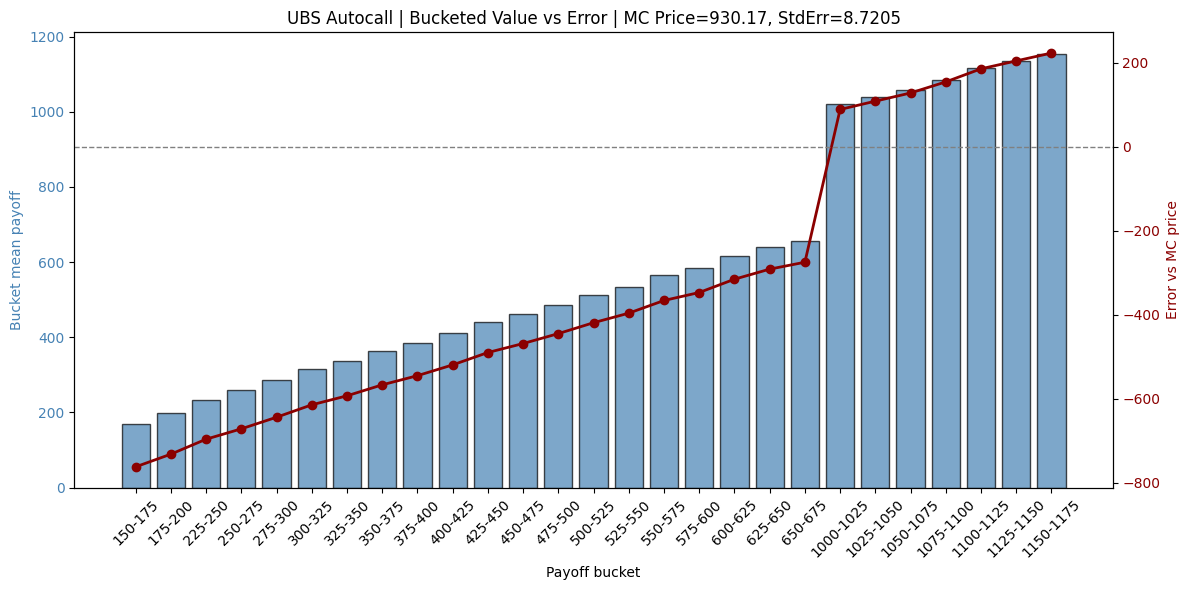

    bucket  count   mean_value  std_value  bucket_error bucket_label
0    150.0      1   168.221777   0.000000   -761.948575      150-175
1    175.0      1   198.458591   0.000000   -731.711760      175-200
2    225.0      5   234.069789   5.321114   -696.100562      225-250
3    250.0      6   258.728493   6.882088   -671.441858      250-275
4    275.0      8   286.355265   6.939545   -643.815086      275-300
5    300.0     10   315.909582   6.020486   -614.260769      300-325
6    325.0      9   337.377523   8.372024   -592.792829      325-350
7    350.0     12   363.492475   7.424729   -566.677877      350-375
8    375.0     15   385.316190   7.843923   -544.854162      375-400
9    400.0     19   410.982159   8.323288   -519.188192      400-425
10   425.0     10   440.452799   9.530341   -489.717552      425-450
11   450.0     21   461.823747   7.626551   -468.346605      450-475
12   475.0     22   485.491732   7.468685   -444.678620      475-500
13   500.0     19   511.422564   8

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from datetime import datetime
from datetime import date


def MC_UBS_Autocall(N, Ntrials,
                    obs_times, pay_times, T, r,
                    S0A, S0B, S0C,
                    sigmaA, sigmaB, sigmaC,
                    qA, qB, qC,
                    rhoAB, rhoAC, rhoBC,
                    principal, coupon,
                    call_barrier, coupon_barrier, downside_barrier):
    """
    Monte Carlo pricer for the UBS Contingent Income Auto-Callable Securities
    with Memory Coupon based on the worst of AAPL, AMZN, GOOGL.

    Uses a single constant volatility per name (sigmaA, sigmaB, sigmaC)
    and continuous dividend yields qA, qB, qC via drift term (r - q).
    """

    monte_result = []
    M = len(obs_times)
    assert len(pay_times) == M, "obs_times and pay_times must have same length"

    # Correlation matrix and Cholesky
    corr = np.array([
        [1.0,   rhoAB, rhoAC],
        [rhoAB, 1.0,   rhoBC],
        [rhoAC, rhoBC, 1.0]
    ])
    L = np.linalg.cholesky(corr)

    for trial in range(1, Ntrials + 1):

        payoff = np.zeros(N)

        for path in range(N):

            # path-level spot variables
            S1 = S0A
            S2 = S0B
            S3 = S0C

            missed_coupons = 0
            autocalled = False

            for j in range(1, M + 1):

                # time step between observation dates
                if j == 1:
                    t_prev = 0.0
                else:
                    t_prev = obs_times[j - 2]
                t_curr = obs_times[j - 1]
                dt = t_curr - t_prev

                # correlated normals
                Z = np.random.normal(0, 1, 3)
                phi = np.dot(L, Z)

                # GBM step with constant vol and continuous dividends
                S1 = S1 * np.exp((r - qA - 0.5 * sigmaA**2) * dt
                                 + sigmaA * np.sqrt(dt) * phi[0])
                S2 = S2 * np.exp((r - qB - 0.5 * sigmaB**2) * dt
                                 + sigmaB * np.sqrt(dt) * phi[1])
                S3 = S3 * np.exp((r - qC - 0.5 * sigmaC**2) * dt
                                 + sigmaC * np.sqrt(dt) * phi[2])

                RA = S1 / S0A
                RB = S2 / S0B
                RC = S3 / S0C
                worst_ratio = min(RA, RB, RC)

                pay_t = pay_times[j - 1]

                # non-final observation dates
                if j < M:
                    # Autocall if all >= call threshold (100% of initial)
                    if (RA >= call_barrier) and (RB >= call_barrier) and (RC >= call_barrier):
                        payoff[path] += np.exp(-r * pay_t) * (principal + coupon * (missed_coupons + 1))
                        autocalled = True
                        break

                    # Coupon if all >= coupon barrier (50% of initial)
                    elif (RA >= coupon_barrier) and (RB >= coupon_barrier) and (RC >= coupon_barrier):
                        payoff[path] += np.exp(-r * pay_t) * (coupon * (missed_coupons + 1))
                        missed_coupons = 0

                    # Otherwise coupon missed, memory increases
                    else:
                        missed_coupons = missed_coupons + 1

                # final observation date (maturity)
                else:
                    # All above downside threshold (50% of initial)
                    if (RA >= downside_barrier) and (RB >= downside_barrier) and (RC >= downside_barrier):

                        # If also above coupon barrier, pay final coupon + memory
                        if (RA >= coupon_barrier) and (RB >= coupon_barrier) and (RC >= coupon_barrier):
                            payoff[path] += np.exp(-r * T) * (principal + coupon * (missed_coupons + 1))
                        else:
                            payoff[path] += np.exp(-r * T) * principal

                    # Worst name below downside threshold: worst-of loss
                    else:
                        payoff[path] += np.exp(-r * T) * principal * worst_ratio

            if autocalled:
                pass

        Value = np.mean(payoff)
        StdErr = np.std(payoff, ddof=1) / np.sqrt(N)

        print("trial =", trial, "Monte =", Value, "StdErr =", StdErr)

        output = {
            'Simulations': N,
            'Monte': Value,
            'StdErr': StdErr,
            'Payoffs': payoff
        }
        monte_result.append(output)

    return monte_result


def UBS_bucketed_error_value_plot(mc_result, bin_width=25):
    """
    mc_result: one element of the monte_result list
               (dict with 'Monte', 'StdErr', 'Payoffs')
    """

    payoffs = np.asarray(mc_result['Payoffs'])
    mc_price = mc_result['Monte']
    mc_stderr = mc_result['StdErr']

    bucket_left = np.floor(payoffs / bin_width) * bin_width

    df_bucket = pd.DataFrame({
        'payoff': payoffs,
        'bucket': bucket_left
    })

    bucket_stats = (
        df_bucket
        .groupby('bucket')
        .agg(
            count=('payoff', 'size'),
            mean_value=('payoff', 'mean'),
            std_value=('payoff', 'std')
        )
        .reset_index()
        .sort_values('bucket')
    )

    bucket_stats['std_value'] = bucket_stats['std_value'].fillna(0.0)
    bucket_stats['bucket_error'] = bucket_stats['mean_value'] - mc_price

    bucket_stats['bucket_label'] = (
        bucket_stats['bucket'].astype(int).astype(str)
        + "-"
        + (bucket_stats['bucket'] + bin_width).astype(int).astype(str)
    )

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.bar(
        bucket_stats['bucket_label'],
        bucket_stats['mean_value'],
        alpha=0.7,
        color='steelblue',
        edgecolor='black',
        label='Mean payoff in bucket'
    )
    ax1.set_xlabel('Payoff bucket')
    ax1.set_ylabel('Bucket mean payoff', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.tick_params(axis='x', rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(
        bucket_stats['bucket_label'],
        bucket_stats['bucket_error'],
        color='darkred',
        marker='o',
        linewidth=2,
        label='Bucket error vs MC price'
    )
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax2.set_ylabel('Error vs MC price', color='darkred')
    ax2.tick_params(axis='y', labelcolor='darkred')

    plt.title(
        f"UBS Autocall | Bucketed Value vs Error | "
        f"MC Price={mc_price:.2f}, StdErr={mc_stderr:.4f}"
    )
    fig.tight_layout()
    plt.show()

    return bucket_stats


if __name__ == "__main__":

    N = 1000
    Ntrials = 10

    obs_times = np.array([94, 185, 276, 367, 458, 549, 640, 731]) / 365.0
    pay_times = np.array([97, 188, 279, 370, 461, 552, 643, 734]) / 365.0

    S0A = 247.99  # Apple
    S0B = 205.37  # Amazon
    S0C = 301.00  # Google

    # OIS DF between T0 and T2 (T0 = 2026‑03‑20, T2 = 2028‑03‑20)
    df_03202028 = 0.931862
    T = (date(2028, 3, 20) - date(2026, 3, 20)).days / 365.0
    r02 = float((-1.0 / T) * np.log(df_03202028))

    # continuous dividends
    qA = 0.00434
    qB = 0.0
    qC = 0.00287

    # Single constant vols per name
    sigmaA = 0.4
    sigmaB = 0.4
    sigmaC = 0.4

    rhoAB = 0.47
    rhoAC = 0.539
    rhoBC = 0.60

    principal = 1000.0
    coupon = 28.875

    call_barrier = 1.00     # 100% of initial
    coupon_barrier = 0.50   # 50% of initial
    downside_barrier = 0.50 # 50% of initial

    mcubs = MC_UBS_Autocall(
        N, Ntrials,
        obs_times, pay_times, T, r02,
        S0A, S0B, S0C,
        sigmaA, sigmaB, sigmaC,
        qA, qB, qC,
        rhoAB, rhoAC, rhoBC,
        principal, coupon,
        call_barrier, coupon_barrier, downside_barrier
    )

    df_ubs = pd.DataFrame.from_dict(mcubs)
    df_ubs_simple = df_ubs[['Simulations', 'Monte', 'StdErr']]
    print(df_ubs_simple)

    bucket_table_ubs = UBS_bucketed_error_value_plot(
        mc_result=mcubs[0],
        bin_width=25
    )
    print(bucket_table_ubs)